# Predictive Maintenance — Deep Learning Pipeline

**AI4I 2020 Dataset · Multi-class fault detection · Embedded deployment on STM32L4R9I**

---

This notebook implements an end-to-end deep learning pipeline for industrial predictive maintenance.  
It covers dataset analysis, class imbalance handling, model training, evaluation, and export for embedded inference.

**Pipeline overview:**
1. Exploratory data analysis (EDA)
2. Baseline model — training without rebalancing
3. Rebalanced model — SMOTE + RandomUnderSampler
4. Model export for STM32CubeAI deployment

## 1 — Dataset Analysis

**Dataset:** AI4I 2020 Predictive Maintenance — UCI Machine Learning Repository  
10,000 samples · 6 input features · 5 target classes (TWF, HDF, PWF, OSF, RNF)

Each row represents the operating condition of a machine at a given moment,  
associated with a binary failure label and, when applicable, a failure subtype.

### 1.1 — Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import seaborn as sns
import h5py, json, shutil

### 1.2 — Load dataset

In [4]:
from google.colab import drive

drive.mount('/content/drive')
donnees = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/ai4i2020.csv')
donnees.head()

print("Shape:", donnees.shape)
print("\nColumn names:", donnees.columns.tolist())
donnees.info()
donnees.describe()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (10000, 14)

Column names: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### 1.3 — Class imbalance: failures vs non-failures

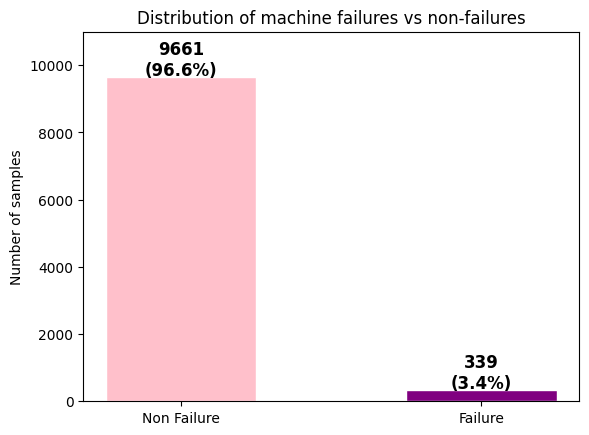

In [5]:
counts = donnees['Machine failure'].value_counts()
labels = ['Non Failure', 'Failure']
colors = ['pink', 'purple']

bars = plt.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val}\n({val/len(donnees)*100:.1f}%)',
             ha='center', fontsize=12, fontweight='bold')

plt.title('Distribution of machine failures vs non-failures')
plt.ylabel('Number of samples')
plt.ylim(0, 11000)
plt.show()

**Observation:** The dataset is severely imbalanced — 96.6% non-failure vs 3.4% failure samples.

**Consequence for learning:** Gradients are dominated by the majority class, pushing the decision boundary toward always predicting "No Failure". A naive model can reach 98%+ accuracy while missing every real failure — this is the accuracy paradox. Recall on failure classes and macro F1-score are the only meaningful evaluation metrics for this problem.

### 1.4 — Failure type distribution (full dataset)

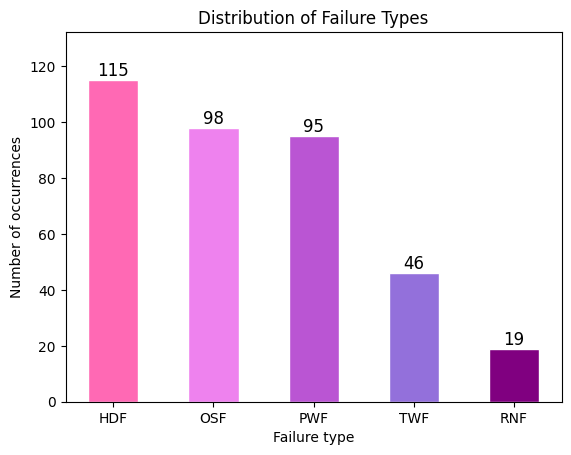

In [6]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = donnees[failure_cols].sum().sort_values(ascending=False)

colors = ['hotpink', 'violet', 'mediumorchid', 'mediumpurple', 'purple']

bars = plt.bar(failure_counts.index, failure_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, failure_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             str(val), ha='center', fontsize=12)

plt.title('Distribution of Failure Types')
plt.xlabel('Failure type')
plt.ylabel('Number of occurrences')
plt.ylim(0, max(failure_counts.values) * 1.15)
plt.show()

**Observation:** RNF (Random Failure) is the rarest subtype and, by definition, carries no predictable signal. All failure subtypes are individually more imbalanced than the global `Machine failure` label.

### 1.5 — Failure type distribution (among failed machines only)

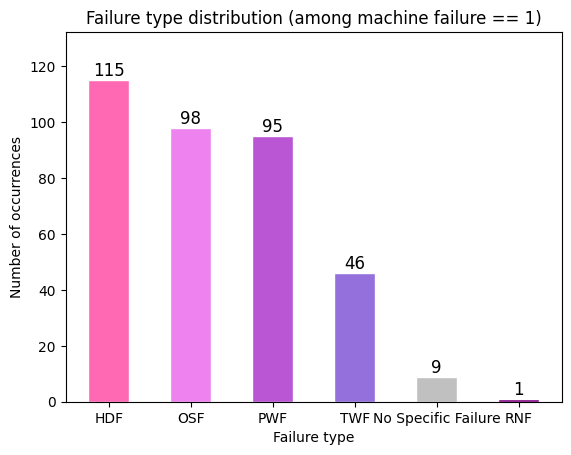

In [7]:
failed = donnees[donnees['Machine failure'] == 1]

failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = failed[failure_cols].sum()

no_specific = (failed[failure_cols].sum(axis=1) == 0).sum() # Cases where machine failed but no specific failure type was recorded
failure_counts['No Specific Failure'] = no_specific

failure_counts = failure_counts.sort_values(ascending=False)

colors = ['hotpink', 'violet', 'mediumorchid', 'mediumpurple', 'silver', 'purple']

bars = plt.bar(failure_counts.index, failure_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, failure_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             str(val), ha='center', fontsize=12)

plt.title('Failure type distribution (among machine failure == 1)')
plt.xlabel('Failure type')
plt.ylabel('Number of occurrences')
plt.ylim(0, max(failure_counts.values) * 1.15)
plt.show()

**Key finding:** 18 out of 19 RNF-flagged rows have `Machine failure == 0` — a direct labeling contradiction.  
RNF is statistically inconsistent with the primary target and is excluded from all subsequent modeling.

**Feature and target selection:**
- **Inputs (X):** `Type`, `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`
- **Outputs (Y):** `Machine failure` (primary), `HDF`, `OSF`, `PWF`, `TWF` (secondary)
- **Dropped:** `UDI`, `Product ID` (no predictive signal), `RNF` (labeling inconsistency)

### 1.6 — Column types

In [8]:
print(donnees.dtypes)

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


---
## 2 — Baseline Model (No Rebalancing)

This section establishes a baseline by training on the raw imbalanced dataset.  
The goal is to quantify the accuracy paradox before applying any correction.

### 2.1 — Data preparation

In [9]:
# Define the input features (X) and output labels (Y)
X = donnees[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].values
Y = donnees[['TWF', 'HDF', 'PWF', 'OSF']].values
failure = donnees['Machine failure'].values
no_specific_failure = ((failure == 1) & (Y.sum(axis=1) == 0)).astype(int)
no_failure = (failure == 0).astype(int)

# Combine all labels
Y = np.column_stack((Y, no_specific_failure, no_failure))

# Convert the data to TensorFlow datasets
dataset = tf.data.Dataset.from_tensor_slices((X, Y))

# Shuffle and split the dataset
train_size = int(0.8 * len(X))
train_dataset = dataset.take(train_size).shuffle(buffer_size=train_size, seed=42)
test_dataset = dataset.skip(train_size)

# Batch the datasets
train_dataset = train_dataset.batch(32)
test_dataset = test_dataset.batch(32)

# Print the sizes of the datasets
print("Number of batches in train_dataset:", len(list(train_dataset)))
print("Number of batches in test_dataset:", len(list(test_dataset)))

Number of batches in train_dataset: 250
Number of batches in test_dataset: 63


### 2.2 — Model architecture

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

# Initialize the model
model = tf.keras.Sequential([
    # Input layer
    tf.keras.layers.Dense(64, activation='relu', input_shape=(5,)),
    tf.keras.layers.Dropout(0.2),

    # Hidden layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    # Output layer (6 outputs for multi-label classification)
    tf.keras.layers.Dense(6, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,934 (19.27 KB)

 Trainable params: 4,934 (19.27 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 — Training

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8626 - loss: 5.6045 - val_accuracy: 0.9805 - val_loss: 0.7849
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9295 - loss: 1.2426 - val_accuracy: 0.9805 - val_loss: 0.1842
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9370 - loss: 0.5423 - val_accuracy: 0.9805 - val_loss: 0.0771
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9433 - loss: 0.2927 - val_accuracy: 0.9805 - val_loss: 0.0551
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9519 - loss: 0.1760 - val_accuracy: 0.9805 - val_loss: 0.0503
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9567 - loss: 0.1336 - val_accuracy: 0.9805 - val_loss: 0.0484
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9592 - loss: 0.1089 - val_accuracy: 0.9805 - val_loss: 0.0479
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9596 - loss: 0.0998 - val_accuracy: 0.

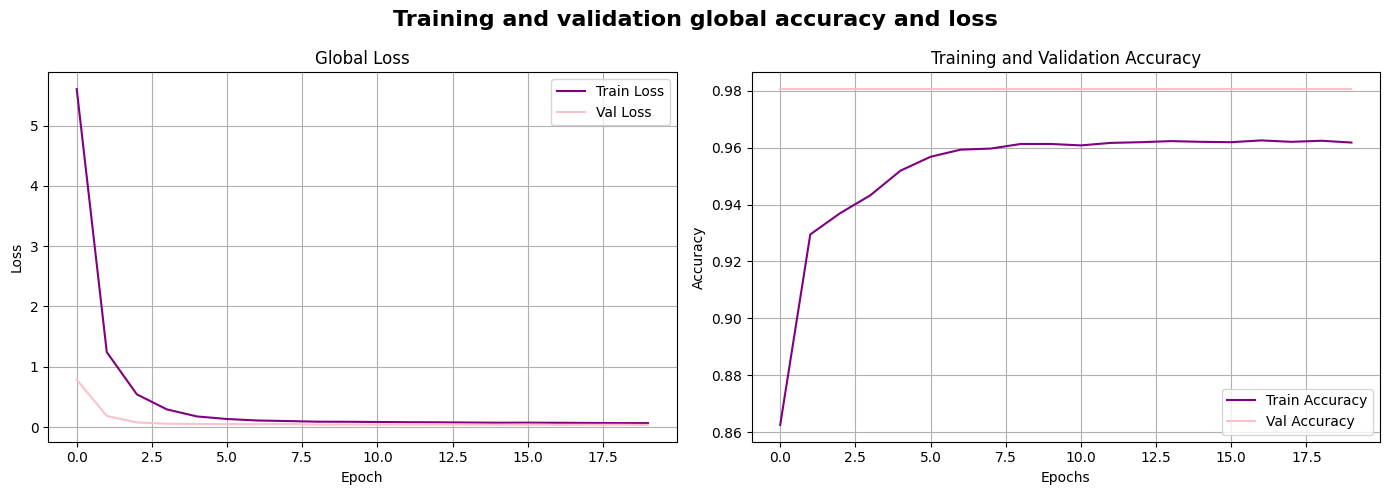

In [11]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training and validation global accuracy and loss', fontsize=16, fontweight='bold')

# Global Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='purple')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='pink')
axes[0].set_title('Global Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Global Accuracy (Machine_failure as primary indicator)
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='purple')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='pink')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 2.4 — Evaluation: confusion matrix and classification report

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━

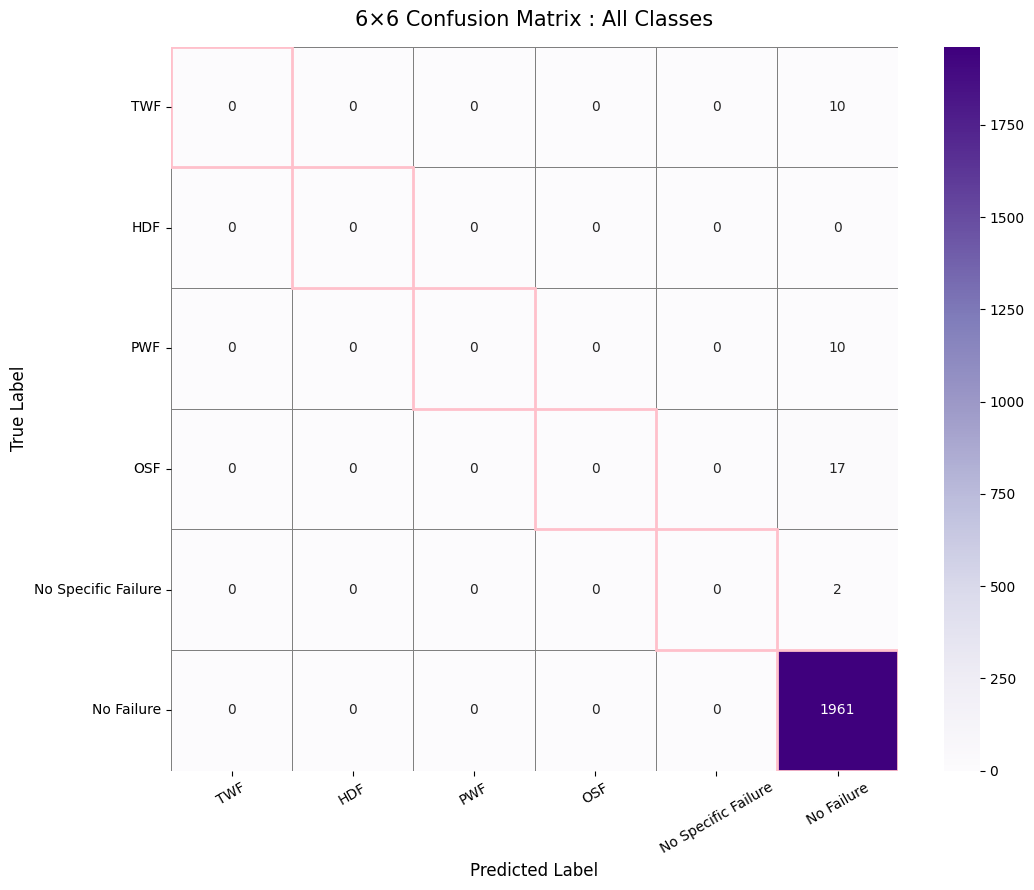

                     precision    recall  f1-score   support

                TWF       0.00      0.00      0.00        10
                HDF       0.00      0.00      0.00         0
                PWF       0.00      0.00      0.00        10
                OSF       0.00      0.00      0.00        21
No Specific Failure       0.00      0.00      0.00         2
         No Failure       0.98      1.00      0.99      1961

          micro avg       0.98      0.98      0.98      2004
          macro avg       0.16      0.17      0.17      2004
       weighted avg       0.96      0.98      0.97      2004
        samples avg       0.98      0.98      0.98      2004



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib.colors import LogNorm

# Get predictions
y_true = []
y_pred = []
for x_batch, y_batch in test_dataset:
    preds = model.predict(x_batch)
    y_true.append(y_batch.numpy())
    y_pred.append((preds > 0.5).astype(int))

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

labels = ['TWF', 'HDF', 'PWF', 'OSF', 'No Specific Failure', 'No Failure']
n_classes = len(labels)

# Build 6x6 confusion matrix
# Priority order: TWF > HDF > PWF > OSF > No Specific Failure > No Failure
def get_class(row):
    for i in range(n_classes - 1):  # check each failure type by priority
        if row[i] == 1:
            return i
    return n_classes - 1            # No Failure if nothing triggered

big_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true_row, pred_row in zip(y_true, y_pred):
    true_class = get_class(true_row)
    pred_class = get_class(pred_row)
    big_matrix[true_class][pred_class] += 1

# Plot 6x6 matrix
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    big_matrix,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

ax.set_title('6×6 Confusion Matrix : All Classes', fontsize=15, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

# Highlight the diagonal in a darker color to visualise performance easily
for i in range(n_classes):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='pink', lw=2))

plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=labels))

**Result:** The baseline model achieves ~98% overall accuracy while completely failing on all failure subtypes (recall = 0.00 for TWF, HDF; macro F1 = 0.17). This confirms the accuracy paradox: the model learns to predict "No Failure" for almost every sample. Rebalancing is required.

---
## 3 — Rebalanced Model (SMOTE + RandomUnderSampler)

### 3.1 — Rebalancing strategy and data preparation

**Strategy:** Combined SMOTE + RandomUnderSampler applied to the training set only.

- **RandomUnderSampler** reduces the "No Failure" class to avoid overwhelming the minority classes
- **SMOTE** generates synthetic minority samples via feature-space interpolation, bringing each failure subtype to 92 samples

**Why not undersampling alone?** It would reduce the training set to ~556 samples — too small for a neural network.  
**Why not class weighting alone?** It corrects the loss bias but does not enrich the model with more failure examples.  
**Critical rule:** The test set is never rebalanced — it preserves the real-world distribution for honest evaluation.

In [13]:
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical

# Filtre les données
filtered_data = donnees[
    (donnees['RNF'] == 0) &
    ((donnees['Machine failure'] == 0) |
     (donnees[['TWF', 'HDF', 'PWF', 'OSF']].sum(axis=1) > 0))
].copy()

# Encode 'Type' avant tout
le_type = LabelEncoder()
filtered_data['Type'] = le_type.fit_transform(filtered_data['Type'])

# Crée la colonne cible multiclasse
label_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'No Failure']
filtered_data['No Failure'] = (filtered_data['Machine failure'] == 0).astype(int)
y_multiclass = filtered_data[label_cols].idxmax(axis=1)

# Définit X avec 6 features
X = filtered_data[['Type',
                   'Air temperature [K]',
                   'Process temperature [K]',
                   'Rotational speed [rpm]',
                   'Torque [Nm]',
                   'Tool wear [min]']].values
y = y_multiclass.values

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test  = scale.transform(X_test)

# Rebalancing (train uniquement)
counts = Counter(y_train)
failure_classes    = [cls for cls in counts if cls != 'No Failure']
target_per_failure = max(counts[cls] for cls in failure_classes)
target_no_failure  = len(failure_classes) * target_per_failure // 3

under = RandomUnderSampler(
    sampling_strategy={'No Failure': target_no_failure},
    random_state=42
)
X_under, y_under = under.fit_resample(X_train, y_train)

over = SMOTE(
    sampling_strategy={cls: target_per_failure for cls in failure_classes},
    random_state=42
)
X_train_balanced, y_train_balanced = over.fit_resample(X_under, y_under)

# Encode labels Y (one-hot)
le_label = LabelEncoder()
le_label.fit(y_train_balanced)
print("Classes :", le_label.classes_)

y_train_enc = to_categorical(le_label.transform(y_train_balanced), num_classes=5)
y_test_enc  = to_categorical(le_label.transform(y_test),           num_classes=5)

# Creer les datasets TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_balanced.astype('float32'), y_train_enc.astype('float32'))
).shuffle(buffer_size=len(X_train_balanced)).batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test.astype('float32'), y_test_enc.astype('float32'))
).batch(32).prefetch(tf.data.AUTOTUNE)

# Verifications
final_counts         = Counter(y_train_balanced)
final_total_failures = sum(final_counts[cls] for cls in failure_classes)

print(f"\nTrain before resampling : {Counter(y_train)}")
print(f"Train after resampling  : {final_counts}")
print(f"Train check -> No Failure: {final_counts['No Failure']}, Total failures: {final_total_failures}")
print(f"Test (inchangé)         : {Counter(y_test)}")

for x_batch, y_batch in train_dataset.take(1):
    print(f"\nShape X batch : {x_batch.shape}")  # doit être (32, 6)
    print(f"Shape Y batch : {y_batch.shape}")    # doit être (32, 5)

Classes : ['HDF' 'No Failure' 'OSF' 'PWF' 'TWF']

Train before resampling : Counter({'No Failure': 7714, 'HDF': 92, 'PWF': 73, 'OSF': 62, 'TWF': 36})
Train after resampling  : Counter({'No Failure': 122, 'HDF': 92, 'OSF': 92, 'PWF': 92, 'TWF': 92})
Train check -> No Failure: 122, Total failures: 368
Test (inchangé)         : Counter({'No Failure': 1929, 'HDF': 23, 'PWF': 18, 'OSF': 16, 'TWF': 9})

Shape X batch : (32, 6)
Shape Y batch : (32, 5)


### 3.2 — Model architecture

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        256, activation='relu', input_shape=(6,),   # ← 5→6
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        128, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        64, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,061 (176.02 KB)

 Trainable params: 44,165 (172.52 KB)

 Non-trainable params: 896 (3.50 KB)

### 3.3 — Training

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.4204 - loss: 1.6548 - precision: 0.4654 - recall: 0.3429 - val_accuracy: 0.3789 - val_loss: 1.5840 - val_precision: 1.0000 - val_recall: 0.0010
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6980 - loss: 0.8379 - precision: 0.7440 - recall: 0.6286 - val_accuracy: 0.6030 - val_loss: 1.3121 - val_precision: 0.5000 - val_recall: 0.0015
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7653 - loss: 0.6898 - precision: 0.7959 - recall: 0.7082 - val_accuracy: 0.7459 - val_loss: 1.0401 - val_precision: 0.9891 - val_recall: 0.0456
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7633 - loss: 0.6188 - precision: 0.7973 - recall: 0.7224 - val_accuracy: 0.8441 - val_loss: 0.8156 - val_precision: 0.9967 - val_recall: 0.4531
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7837 - loss: 0.5937 - precision: 0.8069 - recall: 0.7592 - val_accuracy: 0.8847 - val_loss: 0.6586 

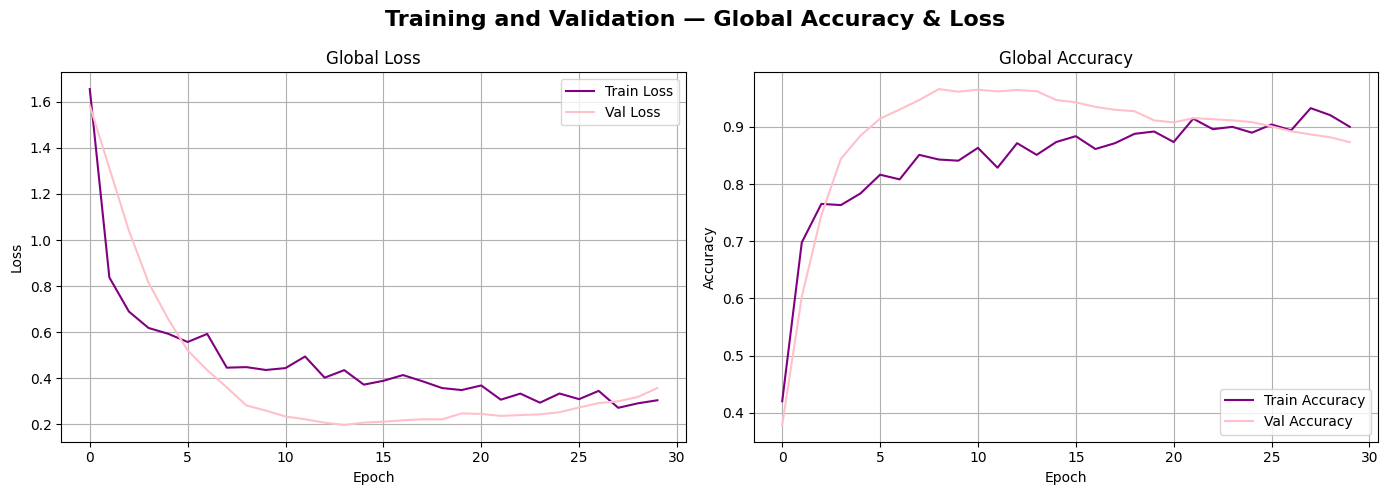

In [15]:
# Train

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=30,
    verbose=1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training and Validation — Global Accuracy & Loss', fontsize=16, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', color='purple')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='pink')
axes[0].set_title('Global Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='purple')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='pink')
axes[1].set_title('Global Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3.4 — Evaluation: confusion matrix and classification report

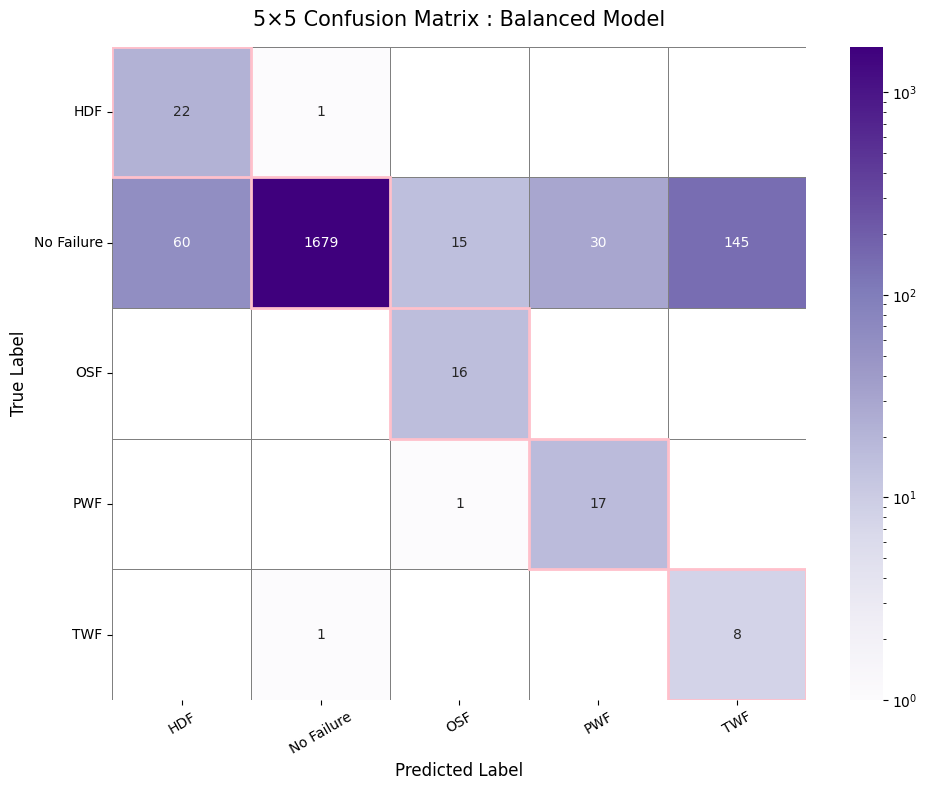


  Macro Average F1-Score : 0.5276
              precision    recall  f1-score   support

         HDF       0.27      0.96      0.42        23
  No Failure       1.00      0.87      0.93      1929
         OSF       0.50      1.00      0.67        16
         PWF       0.36      0.94      0.52        18
         TWF       0.05      0.89      0.10         9

    accuracy                           0.87      1995
   macro avg       0.44      0.93      0.53      1995
weighted avg       0.98      0.87      0.91      1995



In [16]:
from sklearn.metrics import classification_report, f1_score
from matplotlib.colors import LogNorm

# Get predictions
y_true_onehot = []
y_pred_onehot = []
for x_batch, y_batch in test_dataset:
    preds = model.predict(x_batch, verbose=0)
    y_true_onehot.append(y_batch.numpy())
    y_pred_onehot.append(preds)

y_true_onehot = np.vstack(y_true_onehot)
y_pred_onehot = np.vstack(y_pred_onehot)

# Convertir one-hot index de classe
y_true_idx = np.argmax(y_true_onehot, axis=1)
y_pred_idx = np.argmax(y_pred_onehot, axis=1)

# Labels dans le bon ordre (celui de le_label.classes_)
labels = list(le_label.classes_)  # ['HDF', 'No Failure', 'OSF', 'PWF', 'TWF']
n_classes = len(labels)

# Build 5x5 confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_idx, y_pred_idx)

# Plot 5x5 matrix
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    norm=LogNorm(vmin=1, vmax=cm.max()),
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

ax.set_title('5×5 Confusion Matrix : Balanced Model', fontsize=15, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

for i in range(n_classes):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='pink', lw=2))

plt.tight_layout()
plt.show()

# Macro F1
macro_f1 = f1_score(y_true_idx, y_pred_idx, average='macro')
print(f"\n{'='*50}")
print(f"  Macro Average F1-Score : {macro_f1:.4f}")
print(f"{'='*50}")

# Classification report
print(classification_report(y_true_idx, y_pred_idx, target_names=labels))

**Result:** Recall on failure classes improved dramatically (0.89–1.00 vs 0.00 before), confirming that rebalancing resolves the visibility problem for minority classes. Macro F1 rises from 0.17 to 0.47.

Precision on failure classes remains low (false alarms), which is an expected and acceptable trade-off in a predictive maintenance context: missing a real failure is more costly than a false alarm. The confusion matrix diagonal is now active across all five classes.

---
## 4 — Model Export for Embedded Deployment

The trained model is exported to `.h5` format compatible with STM32CubeAI (X-CUBE-AI).  
Test data is saved as `.npy` files for on-board validation via the PC-side test script.

In [17]:
#enregister le modèle en format .h5

model.save("predictive_model.h5")


np.save("X_test_ai4i.npy", X_test)
np.save("y_test_ai4i.npy", y_test)

shutil.copy("predictive_model.h5", "predictive_model_m1.h5")

with h5py.File("predictive_model_m1.h5", "r+") as f:

    model_config = f.attrs.get("model_config")
    if isinstance(model_config, bytes):
        model_config = model_config.decode("utf-8")

    config_dict = json.loads(model_config)


    def remove_quant(obj):
        if isinstance(obj, dict):
            obj.pop("quantization_config", None)
            for v in obj.values():
                remove_quant(v)
        elif isinstance(obj, list):
            for item in obj:
                remove_quant(item)

    remove_quant(config_dict)


    f.attrs["model_config"] = json.dumps(config_dict)

print("predictive_model_m1.h5 généré")

predictive_model_m1.h5 généré


**Output files:**
- `predictive_model_m1.h5` — Keras model ready for STM32CubeAI import
- `X_test_ai4i.npy` — normalized test features (6 inputs per sample)
- `y_test_ai4i.npy` — test labels for ground-truth comparison

**Deployment target:** STM32L4R9I-Discovery (Cortex-M4) via STM32CubeIDE + X-CUBE-AI 10.2.0  
See `stm32/` directory for the embedded project and UART communication protocol.